In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
from tensorflow import keras
from tensorflow.keras.datasets import cifar10

In [133]:
(x_train_org, y_train_org), (x_test, y_test) = cifar10.load_data()

In [134]:
x_train = x_train_org.astype("float32")
x_test = x_test.astype("float32")

(array([5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000.,
        5000.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <a list of 10 Patch objects>)

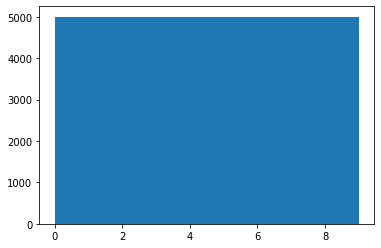

In [135]:
plt.hist(y_train_org)

In [136]:
x_train = x_train_org[:len(x_train_org)//2]
y_train = y_train_org[:len(y_train_org)//2]

(array([2491., 2518., 2515., 2522., 2490., 2411., 2537., 2530., 2507.,
        2479.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <a list of 10 Patch objects>)

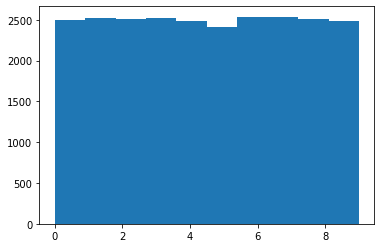

In [137]:
plt.hist(y_train)

I used (about) 50% of data from each classes.

In [138]:
IMG_SHAPE = x_train[0].shape
NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer", 
                   "dog", "frog", "horse", "ship", "truck"]

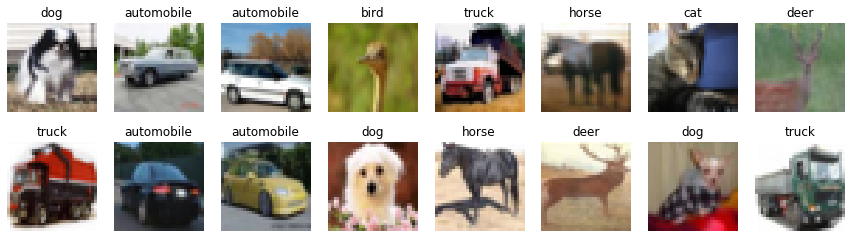

In [139]:
# show random images from train
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index, 0]])
plt.show()

In [140]:
print("Train Samples: ", x_train.shape, y_train.shape)
print("Test Samples: ", x_test.shape, y_test.shape)

Train Samples:  (25000, 32, 32, 3) (25000, 1)
Test Samples:  (10000, 32, 32, 3) (10000, 1)


In [141]:
# TODO: limit data

I need to normalize inputs like this:

$$
x_\mathrm{norm} = \frac{x}{255} - 0.5
$$

I also need to convert class labels to one-hot encoded vectors. In this case, I used `keras.utils.to_categorical`.

In [142]:
# normalize inputs
x_train_normed = x_train / 255 - 0.5 
x_test_normed = x_test / 255 - 0.5 

# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)

In [143]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, InputLayer, Reshape, Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, LeakyReLU, Conv2DTranspose)

# Convolutional autoencoder
## Encoder
The encoder part is pretty standard, we stack convolutional and pooling layers and finish with a dense layer to get the representation of desirable size (code_size).

We recommend to use activation='elu' for all convolutional and dense layers.

We recommend to repeat (conv, pool) 4 times with kernel size (3, 3), padding='same' and the following numbers of output channels: 32, 64, 128, 256.

Remember to flatten (L.Flatten()) output before adding the last dense layer!

## Decoder
For decoder we will use so-called "transpose convolution".

Traditional convolutional layer takes a patch of an image and produces a number (patch -> number). In "transpose convolution" we want to take a number and produce a patch of an image (number -> patch). We need this layer to "undo" convolutions in encoder. We had a glimpse of it during week 3 (watch this video starting at 5:41).

In [144]:

def build_deep_autoencoder(img_shape, code_size):
    """PCA's deeper brother. See instructions above. Use `code_size` in layer definitions."""
    H,W,C = img_shape
    
    # encoder
    encoder = keras.models.Sequential()
    encoder.add(InputLayer(img_shape))
    ### YOUR CODE HERE: define encoder as per instructions above ###    
    # 
    encoder.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same'))
    encoder.add(MaxPooling2D(pool_size=(2, 2)))
    encoder.add(Activation('elu'))
    #
    encoder.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same'))
    encoder.add(MaxPooling2D(pool_size=(2, 2)))
    encoder.add(Activation('elu'))    
    #
    encoder.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same'))
    encoder.add(MaxPooling2D(pool_size=(2, 2)))
    encoder.add(Activation('elu'))    
    #
    encoder.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same'))
    encoder.add(MaxPooling2D(pool_size=(2, 2)))
    encoder.add(Activation('elu'))    
    #
    encoder.add(Flatten())
    encoder.add(Dense(code_size))
    encoder.add(Activation('elu'))
    # decoder
    decoder = keras.models.Sequential()
    decoder.add(InputLayer((code_size,)))
    decoder.add(Dense(2*2*256))
    decoder.add(Reshape((2, 2, 256)))
#     decoder.add(L.Dense(int(H/16)*int(W/16)*3))
#     decoder.add(L.Reshape((int(H/16), int(W/16), 3))) #un-flatten
    ### YOUR CODE HERE: define decoder as per instructions above ###
    # そもそものOperationがMaxpoolingの逆．MaxPoolingはいらん
    decoder.add(Conv2DTranspose(filters=128, kernel_size=(3, 3), strides=2, activation='elu', padding='same'))
    #
    decoder.add(Conv2DTranspose(filters=64, kernel_size=(3, 3), strides=2, activation='elu', padding='same'))
    #
    decoder.add(Conv2DTranspose(filters=32, kernel_size=(3, 3), strides=2, activation='elu', padding='same'))
    #
    decoder.add(Conv2DTranspose(filters=3, kernel_size=(3, 3), strides=2, activation='elu', padding='same'))    
    return encoder, decoder

In [145]:
get_dim = lambda layer: np.prod(layer.output_shape[1:])
for code_size in [1, 8, 32, 128, 512]:
    encoder, decoder = build_deep_autoencoder(IMG_SHAPE, code_size=code_size)
    print("Testing code size %i" % code_size)
    assert encoder.output_shape[1:] == (code_size,),"encoder must output a code of required size"
    assert decoder.output_shape[1:] == IMG_SHAPE,   "decoder must output an image of valid shape {} and {}".format(
        decoder.output_shape[1:], IMG_SHAPE
    )
    assert len(encoder.trainable_weights) >= 6,     "encoder must contain at least 3 layers"
    assert len(decoder.trainable_weights) >= 6,     "decoder must contain at least 3 layers"

    for layer in encoder.layers + decoder.layers:
        assert get_dim(layer) >= code_size, "Encoder layer %s is smaller than bottleneck (%i units) %i"%(layer.name,get_dim(layer), code_size)

print("All tests passed!")

Testing code size 1
Testing code size 8
Testing code size 32
Testing code size 128
Testing code size 512
All tests passed!


In [146]:
from tensorflow import keras
import tqdm
from collections import defaultdict
import numpy as np


class TqdmProgressCallback(keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.epochs = self.params['epochs']

    def on_epoch_begin(self, epoch, logs=None):
        print('Epoch %d/%d' % (epoch + 1, self.epochs))
        if "steps" in self.params:
            self.use_steps = True
            self.target = self.params['steps']
        else:
            self.use_steps = False
            self.target = self.params['samples']
        self.prog_bar = tqdm.tqdm_notebook(total=self.target)
        self.log_values_by_metric = defaultdict(list)

    def _set_prog_bar_desc(self, logs):
        for k in self.params['metrics']:
            if k in logs:
                self.log_values_by_metric[k].append(logs[k])
        desc = "; ".join("{0}: {1:.3f}".format(k, np.mean(values)) for k, values in self.log_values_by_metric.items())
        self.prog_bar.set_description(desc)

    def on_batch_end(self, batch, logs=None):
        logs = logs or {}
        if self.use_steps:
            self.prog_bar.update(1)
        else:
            batch_size = logs.get('size', 0)
            self.prog_bar.update(batch_size)
        self._set_prog_bar_desc(logs)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self._set_prog_bar_desc(logs)
        self.prog_bar.update(1)  # workaround to show description
        self.prog_bar.close()

In [147]:
encoder, decoder = build_deep_autoencoder(IMG_SHAPE, code_size=32)

In [148]:
encoder.summary()

Model: "sequential_46"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_92 (Conv2D)           (None, 32, 32, 32)        896       
_________________________________________________________________
max_pooling2d_92 (MaxPooling (None, 16, 16, 32)        0         
_________________________________________________________________
activation_115 (Activation)  (None, 16, 16, 32)        0         
_________________________________________________________________
conv2d_93 (Conv2D)           (None, 16, 16, 64)        18496     
_________________________________________________________________
max_pooling2d_93 (MaxPooling (None, 8, 8, 64)          0         
_________________________________________________________________
activation_116 (Activation)  (None, 8, 8, 64)          0         
_________________________________________________________________
conv2d_94 (Conv2D)           (None, 8, 8, 128)       

In [149]:
decoder.summary()

Model: "sequential_47"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_47 (Dense)             (None, 1024)              33792     
_________________________________________________________________
reshape_23 (Reshape)         (None, 2, 2, 256)         0         
_________________________________________________________________
conv2d_transpose_92 (Conv2DT (None, 4, 4, 128)         295040    
_________________________________________________________________
conv2d_transpose_93 (Conv2DT (None, 8, 8, 64)          73792     
_________________________________________________________________
conv2d_transpose_94 (Conv2DT (None, 16, 16, 32)        18464     
_________________________________________________________________
conv2d_transpose_95 (Conv2DT (None, 32, 32, 3)         867       
Total params: 421,955
Trainable params: 421,955
Non-trainable params: 0
_______________________________________________

In [150]:
autoencoder.fit(x=x_train_normed, y=x_train_normed, epochs=10,
                validation_split=0.2,
                callbacks=[TqdmProgressCallback()],
                verbose=0)

Epoch 1/10


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`



Epoch 2/10



Epoch 3/10



Epoch 4/10


...


Epoch 6/10



Epoch 7/10



Epoch 8/10



Epoch 9/10



Epoch 10/10


In [155]:
def show_image(x):
#     plt.imshow(x)
    plt.imshow(np.clip(x + 0.5, 0, 1))

In [156]:
def visualize(img,encoder,decoder):
    """Draws original, encoded and decoded images"""
    code = encoder.predict(img[None])[0]  # img[None] is the same as img[np.newaxis, :]
    reco = decoder.predict(code[None])[0]

    plt.subplot(1,3,1)
    plt.title("Original")
    show_image(img)

    plt.subplot(1,3,2)
    plt.title("Code")
    plt.imshow(code.reshape([code.shape[-1]//2,-1]))
    plt.subplot(1,3,3)
    plt.title("Reconstructed")
    show_image(reco)
    plt.show()


Convolutional autoencoder MSE: 0.007393784280121327


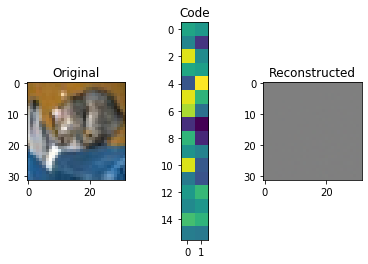

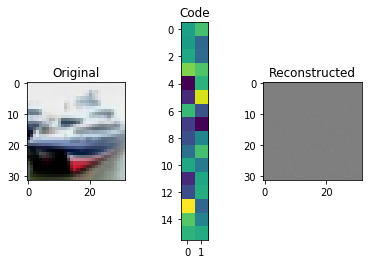

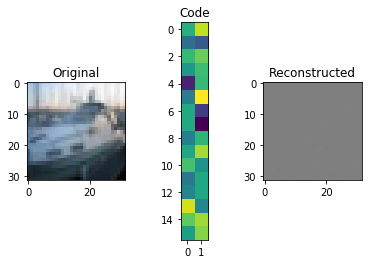

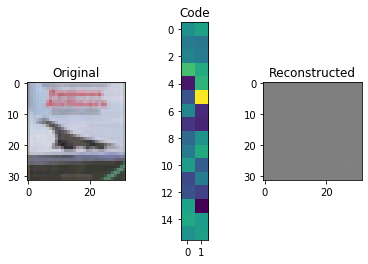

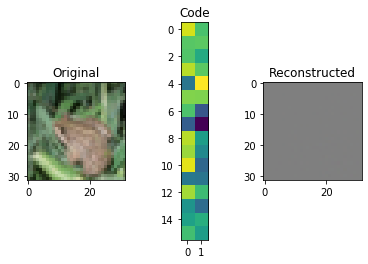

In [158]:
reconstruction_mse = autoencoder.evaluate(x_test_normed, x_test_normed, verbose=0)
print("Convolutional autoencoder MSE:", reconstruction_mse)
for i in range(5):
    img = x_test_normed[i]
    visualize(img,encoder,decoder)